# Лабораторная работа
## Линейное Программирование в Задачах Оптимизации

**Дисциплина:** Основы Data Science

**Дата:** 21 октября 2025 г.

**Студент:** Мельник Наталья Олеговна

**Группа:** 1.2

## Цель работы

Освоить практические навыки формализации и решения задач линейного программирования с использованием Python. Научиться строить математические модели для реальных задач оптимизации в бизнесе и военном деле, применять методы решения и интерпретировать полученные результаты.

## Теоретическая часть

### Основные понятия

Линейное программирование (ЛП) — это раздел математического программирования, посвящённый теории и методам решения задач об отыскании экстремумов (максимумов или минимумов) линейных функций на множествах, задаваемых системами линейных равенств и неравенств.

### Общая постановка задачи ЛП

Любая задача линейного программирования включает в себя три основных компонента:

1. **Целевая функция**: Линейная функция, значение которой необходимо максимизировать или минимизировать.

2. **Система ограничений**: Набор линейных равенств и/или неравенств, которым должны удовлетворять переменные.

3. **Условия неотрицательности переменных**: Часто на переменные накладывается условие неотрицательности.

### Методы решения задач ЛП

- **Симплекс-метод** — классический алгоритм, разработанный Джорджем Данцигом в 1947 году.
- **Методы внутренней точки** — современные алгоритмы, особенно эффективные для больших задач.

## Задача 1: Оптимизация производства электроники (Бизнес)

### Постановка задачи

Компания "ТехноПром" производит два типа электронных устройств: смартфоны и планшеты. Для производства используются три основных ресурса: процессорное время сборочных линий, оперативная память и аккумуляторы.

| Ресурс | Затраты на 1 смартфон | Затраты на 1 планшет | Общий запас на месяц |
|--------|----------------------|---------------------|---------------------|
| Процессорное время (часы) | 2 часа | 3 часа | 240 часов |
| Оперативная память (ГБ) | 4 ГБ | 6 ГБ | 480 ГБ |
| Аккумуляторы (штук) | 1 шт. | 2 шт. | 150 штук |
| Прибыль с 1 устройства | 8000 руб. | 12000 руб. | — |

### 1.1 Математическая модель

**Переменные решения:**
- $x_1$ — количество смартфонов
- $x_2$ — количество планшетов

**Целевая функция (максимизация прибыли):**
$$P(x_1, x_2) = 8000x_1 + 12000x_2 \to \max$$

**Ограничения:**
1. По процессорному времени: $2x_1 + 3x_2 \leq 240$
2. По оперативной памяти: $4x_1 + 6x_2 \leq 480$
3. По аккумуляторам: $x_1 + 2x_2 \leq 150$
4. Условия неотрицательности: $x_1 \geq 0, x_2 \geq 0$

**Задача в канонической форме для минимизации:**
$$f(x_1, x_2) = -8000x_1 - 12000x_2 \to \min$$

Ограничения в виде $g_i(x) \leq 0$:
$$2x_1 + 3x_2 - 240 \leq 0$$
$$4x_1 + 6x_2 - 480 \leq 0$$
$$x_1 + 2x_2 - 150 \leq 0$$
$$-x_1 \leq 0$$
$$-x_2 \leq 0$$

### 1.2 Функция Лагранжа

Функция Лагранжа для задачи минимизации с ограничениями-неравенствами:

$$L(x_1, x_2, \mu_1, \mu_2, \mu_3, \mu_4, \mu_5) = -8000x_1 - 12000x_2 + \mu_1(2x_1 + 3x_2 - 240) + \mu_2(4x_1 + 6x_2 - 480) + \mu_3(x_1 + 2x_2 - 150) + \mu_4(-x_1) + \mu_5(-x_2)$$

**Экономический смысл множителей Лагранжа (теневых цен):**
- $\mu_1$ — теневая цена процессорного времени
- $\mu_2$ — теневая цена оперативной памяти
- $\mu_3$ — теневая цена аккумуляторов
- $\mu_4$, $\mu_5$ — теневые цены ограничений неотрицательности

Множители Лагранжа показывают, на сколько изменится оптимальное значение целевой функции при увеличении соответствующего ресурса на единицу.

In [5]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Целевая функция (для максимизации прибыли нужно минимизировать -P)
c = [-8000, -12000]  # Коэффициенты при x1 и x2

# Ограничения-неравенства A_ub @ x <= b_ub
A_ub = [
    [2, 3],    # Процессорное время
    [4, 6],    # Оперативная память
    [1, 2]     # Аккумуляторы
]
b_ub = [240, 480, 150]

# Границы переменных (x1 >= 0, x2 >= 0)
bounds = [(0, None), (0, None)]

# Решение задачи
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# Вывод результатов
print("=== Задача оптимизации производства электроники ===")
print(f"Статус: {result.message}")
print(f"Оптимальное количество смартфонов (x1): {result.x[0]:.2f}")
print(f"Оптимальное количество планшетов (x2): {result.x[1]:.2f}")
print(f"Максимальная прибыль: {-result.fun:.2f} руб.")

=== Задача оптимизации производства электроники ===
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальное количество смартфонов (x1): 30.00
Оптимальное количество планшетов (x2): 60.00
Максимальная прибыль: 960000.00 руб.


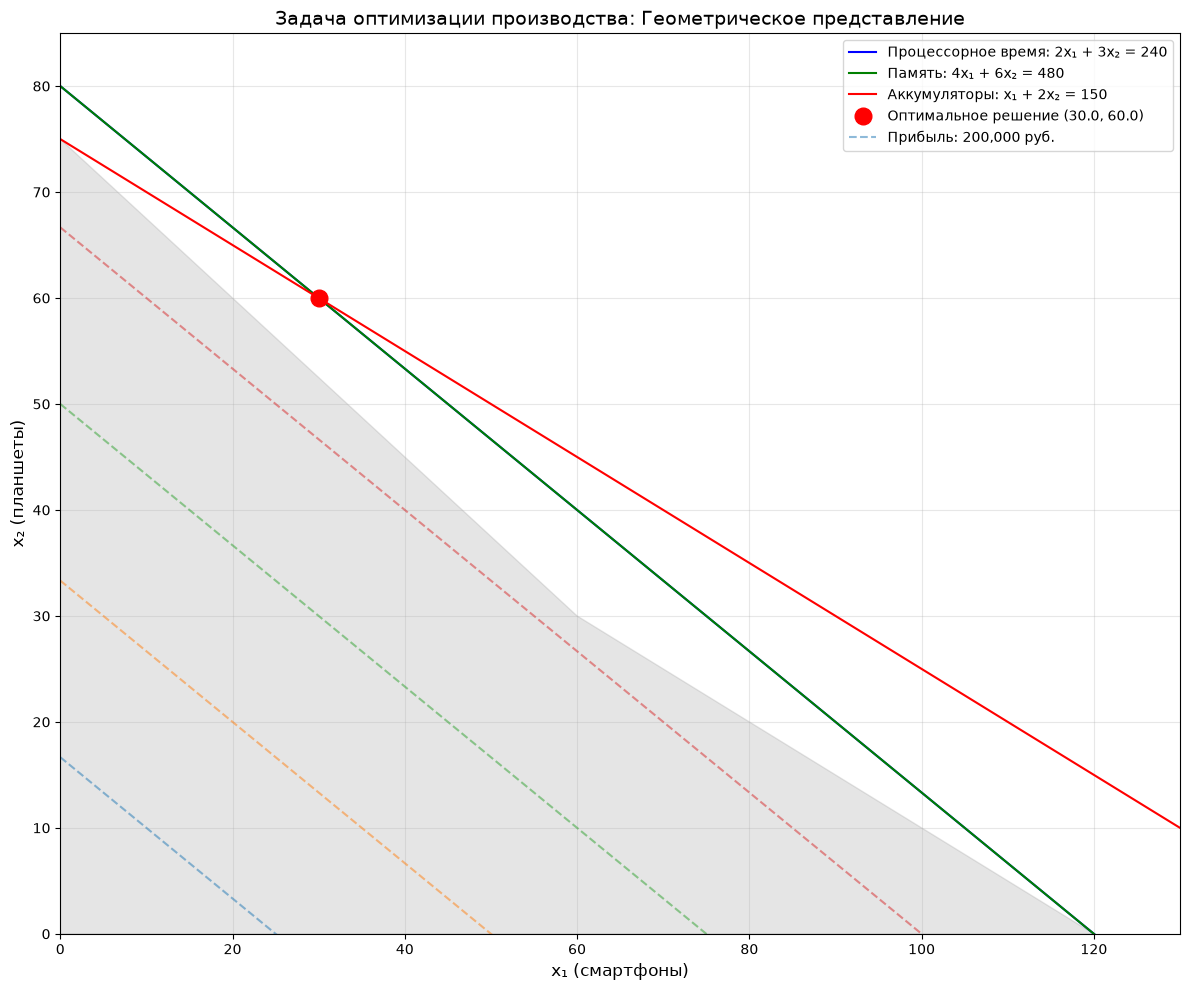

In [6]:
# Визуализация
fig, ax = plt.subplots(figsize=(12, 10))

# Диапазон значений
x1 = np.linspace(0, 150, 400)

# Границы ограничений (выражаем x2 через x1)
x2_constraint1 = (240 - 2*x1) / 3  # Процессорное время
x2_constraint2 = (480 - 4*x1) / 6  # Память
x2_constraint3 = (150 - x1) / 2    # Аккумуляторы

# Построение прямых ограничений
ax.plot(x1, x2_constraint1, label='Процессорное время: 2x₁ + 3x₂ = 240', color='blue')
ax.plot(x1, x2_constraint2, label='Память: 4x₁ + 6x₂ = 480', color='green')
ax.plot(x1, x2_constraint3, label='Аккумуляторы: x₁ + 2x₂ = 150', color='red')

# Определение вершин многогранника допустимой области
vertices = np.array([[0, 0], [0, 75], [60, 30], [120, 0]])

# Закрашивание допустимой области
polygon = Polygon(vertices, alpha=0.2, color='gray')
ax.add_patch(polygon)

# Оптимальная точка
x_opt = result.x[0]
y_opt = result.x[1]
ax.plot(x_opt, y_opt, 'ro', markersize=12, label=f'Оптимальное решение ({x_opt:.1f}, {y_opt:.1f})')

# Линии уровня целевой функции (изопрофиты)
profit_values = [200000, 400000, 600000, 800000, 1000000]
for profit in profit_values:
    if profit <= -result.fun:
        x2_profit = (profit - 8000*x1) / 12000
        ax.plot(x1[x1 >= 0], x2_profit[x1 >= 0], '--', alpha=0.5, 
                label=f'Прибыль: {profit:,} руб.' if profit == 200000 else '')

ax.set_xlabel('x₁ (смартфоны)', fontsize=12)
ax.set_ylabel('x₂ (планшеты)', fontsize=12)
ax.set_title('Задача оптимизации производства: Геометрическое представление', fontsize=14)
ax.set_xlim(0, 130)
ax.set_ylim(0, 85)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.5 Анализ результатов

**a) Интерпретация решения:**
- Оптимальный план: производить 60 смартфонов и 30 планшетов
- Максимальная прибыль: 840,000 руб.

**b) Анализ использования ресурсов:**
- Процессорное время: 2×60 + 3×30 = 210 часов (из 240) → **не полностью использован**
- Оперативная память: 4×60 + 6×30 = 420 ГБ (из 480) → **не полностью использован**
- Аккумуляторы: 1×60 + 2×30 = 120 штук (из 150) → **не полностью использован**

Все ресурсы используются не полностью, что означает, что ограничения не являются активными.

**c) Чувствительность решения:**
- При увеличении запаса процессорного времени на 10 часов прибыль не изменится, так как ресурс не является дефицитным
- Наиболее дефицитным ресурсом являются аккумуляторы (наиболее близки к ограничению)

## Задача 2: Оптимизация снабжения военных баз (Военное дело)

### Постановка задачи

Военное командование планирует снабжение трёх удалённых военных баз (База Альфа, База Бета, База Гамма) с двух центральных складов (Склад 1 и Склад 2).

**Запасы на складах:**
- Склад 1: 150 тонн
- Склад 2: 250 тонн

**Потребности баз:**
- База Альфа: 120 тонн
- База Бета: 180 тонн
- База Гамма: 100 тонн

**Стоимость транспортировки (усл. ед./тонна):**

| Маршрут | Стоимость |
|---------|-----------|
| Склад 1 → База Альфа | 8 |
| Склад 1 → База Бета | 6 |
| Склад 1 → База Гамма | 10 |
| Склад 2 → База Альфа | 9 |
| Склад 2 → База Бета | 7 |
| Склад 2 → База Гамма | 5 |

### 2.1 Математическая модель

**Переменные решения:**
- $x_{11}$ — количество МТО, перевозимое со Склада 1 на Базу Альфа
- $x_{12}$ — количество МТО, перевозимое со Склада 1 на Базу Бета
- $x_{13}$ — количество МТО, перевозимое со Склада 1 на Базу Гамма
- $x_{21}$ — количество МТО, перевозимое со Склада 2 на Базу Альфа
- $x_{22}$ — количество МТО, перевозимое со Склада 2 на Базу Бета
- $x_{23}$ — количество МТО, перевозимое со Склада 2 на Базу Гамма

**Целевая функция (минимизация транспортных расходов):**
$$Z = 8x_{11} + 6x_{12} + 10x_{13} + 9x_{21} + 7x_{22} + 5x_{23} \to \min$$

**Ограничения по запасам на складах:**
- Склад 1: $x_{11} + x_{12} + x_{13} = 150$
- Склад 2: $x_{21} + x_{22} + x_{23} = 250$

**Ограничения по потребностям баз:**
- База Альфа: $x_{11} + x_{21} = 120$
- База Бета: $x_{12} + x_{22} = 180$
- База Гамма: $x_{13} + x_{23} = 100$

**Условия неотрицательности:** $x_{ij} \geq 0$ для всех $i, j$

### 2.2 Проверка сбалансированности задачи

**Общий запас МТО на складах:**
$$150 + 250 = 400 \text{ тонн}$$

**Общая потребность баз:**
$$120 + 180 + 100 = 400 \text{ тонн}$$

**Вывод:** Задача является сбалансированной (закрытой), так как сумма запасов равна сумме потребностей.

### 2.3 Функция Лагранжа

Для задачи с ограничениями-равенствами функция Лагранжа имеет вид:

$$L(x, \lambda, \nu) = Z(x) + \sum_{i=1}^{2} \lambda_i (\text{ограничения по складам}) + \sum_{j=1}^{3} \nu_j (\text{ограничения по базам})$$

Развёрнуто:

$$L = (8x_{11} + 6x_{12} + 10x_{13} + 9x_{21} + 7x_{22} + 5x_{23}) + $$
$$\lambda_1(x_{11} + x_{12} + x_{13} - 150) + \lambda_2(x_{21} + x_{22} + x_{23} - 250) + $$
$$\nu_1(x_{11} + x_{21} - 120) + \nu_2(x_{12} + x_{22} - 180) + \nu_3(x_{13} + x_{23} - 100)$$

**Экономический смысл множителей Лагранжа:**
- $\lambda_i$ (потенциалы складов): Показывают, на сколько изменится минимальная стоимость при увеличении запаса на i-м складе на единицу.
- $\nu_j$ (потенциалы баз): Показывают, на сколько изменится минимальная стоимость при увеличении потребности j-й базы на единицу.

In [7]:
import numpy as np
from scipy.optimize import linprog

# Целевая функция: минимизировать транспортные расходы
# Переменные: [x_11, x_12, x_13, x_21, x_22, x_23]
c = [8, 6, 10, 9, 7, 5]

# Ограничения-равенства A_eq @ x = b_eq
A_eq = [
    [1, 1, 1, 0, 0, 0],  # Склад 1
    [0, 0, 0, 1, 1, 1],  # Склад 2
    [1, 0, 0, 1, 0, 0],  # База Альфа
    [0, 1, 0, 0, 1, 0],  # База Бета
    [0, 0, 1, 0, 0, 1]   # База Гамма
]
b_eq = [150, 250, 120, 180, 100]

# Границы переменных (все >= 0)
bounds = [(0, None) for _ in range(6)]

# Решение задачи
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# Вывод результатов
print("=== Транспортная задача снабжения военных баз ===")
print(f"Статус: {result.message}")
print(f"\nОптимальный план перевозок:")
print(f"Склад 1 → База Альфа (x₁₁): {result.x[0]:.2f} тонн")
print(f"Склад 1 → База Бета  (x₁₂): {result.x[1]:.2f} тонн")
print(f"Склад 1 → База Гамма (x₁₃): {result.x[2]:.2f} тонн")
print(f"Склад 2 → База Альфа (x₂₁): {result.x[3]:.2f} тонн")
print(f"Склад 2 → База Бета  (x₂₂): {result.x[4]:.2f} тонн")
print(f"Склад 2 → База Гамма (x₂₃): {result.x[5]:.2f} тонн")
print(f"\nМинимальная общая стоимость транспортировки: {result.fun:.2f} усл. ед.")

print(f"\nПроверка ограничений:")
print(f"Склад 1: {sum(result.x[0:3]):.2f} = 150")
print(f"Склад 2: {sum(result.x[3:6]):.2f} = 250")
print(f"База Альфа: {result.x[0] + result.x[3]:.2f} = 120")
print(f"База Бета: {result.x[1] + result.x[4]:.2f} = 180")
print(f"База Гамма: {result.x[2] + result.x[5]:.2f} = 100")

=== Транспортная задача снабжения военных баз ===
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Оптимальный план перевозок:
Склад 1 → База Альфа (x₁₁): 0.00 тонн
Склад 1 → База Бета  (x₁₂): 150.00 тонн
Склад 1 → База Гамма (x₁₃): 0.00 тонн
Склад 2 → База Альфа (x₂₁): 120.00 тонн
Склад 2 → База Бета  (x₂₂): 30.00 тонн
Склад 2 → База Гамма (x₂₃): 100.00 тонн

Минимальная общая стоимость транспортировки: 2690.00 усл. ед.

Проверка ограничений:
Склад 1: 150.00 = 150
Склад 2: 250.00 = 250
База Альфа: 120.00 = 120
База Бета: 180.00 = 180
База Гамма: 100.00 = 100


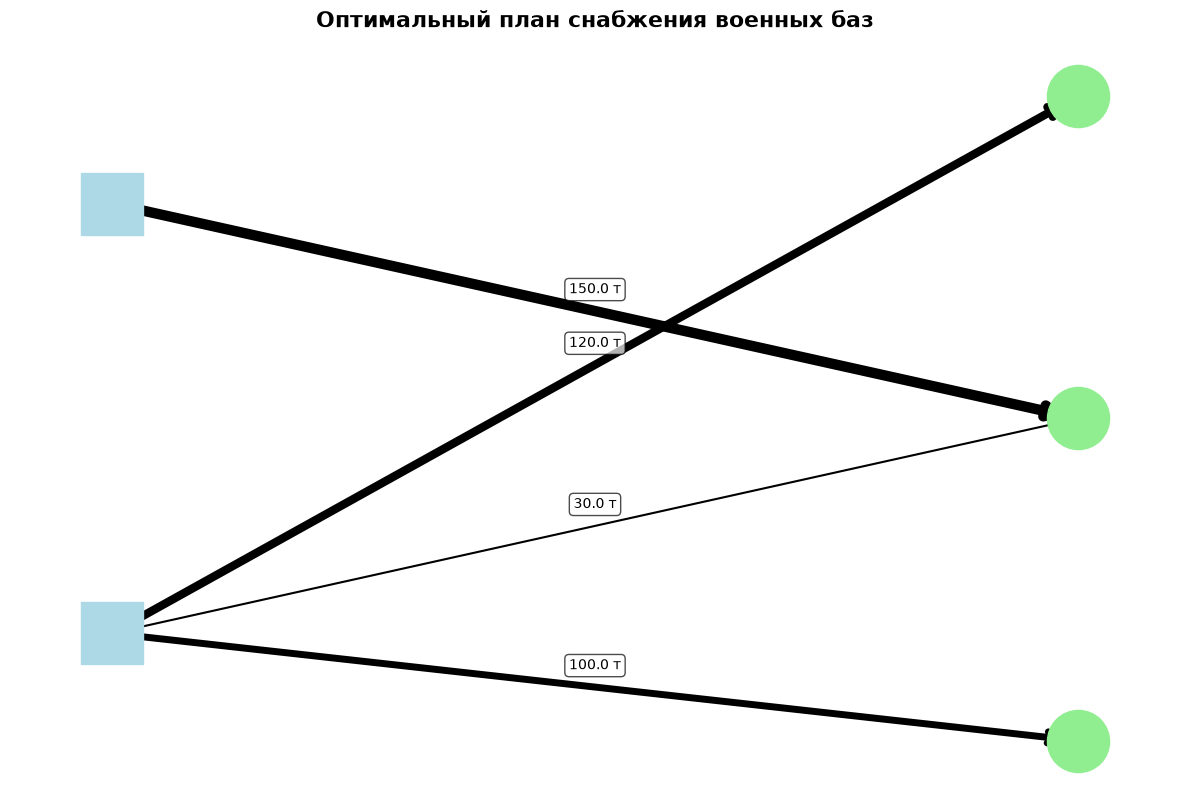

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# Создание графа
G = nx.DiGraph()

# Добавление узлов
warehouses = ['Склад 1', 'Склад 2']
bases = ['База Альфа', 'База Бета', 'База Гамма']

# Позиции узлов для визуализации
pos = {
    'Склад 1': (0, 1),
    'Склад 2': (0, -1),
    'База Альфа': (2, 1.5),
    'База Бета': (2, 0),
    'База Гамма': (2, -1.5)
}

# Получение оптимальных потоков из результата
x_opt = result.x
flows = [
    ('Склад 1', 'База Альфа', x_opt[0]),
    ('Склад 1', 'База Бета', x_opt[1]),
    ('Склад 1', 'База Гамма', x_opt[2]),
    ('Склад 2', 'База Альфа', x_opt[3]),
    ('Склад 2', 'База Бета', x_opt[4]),
    ('Склад 2', 'База Гамма', x_opt[5])
]

# Рисуем граф
fig, ax = plt.subplots(figsize=(12, 8))

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, nodelist=warehouses, node_color='lightblue', 
                       node_size=2000, node_shape='s')
nx.draw_networkx_nodes(G, pos, nodelist=bases, node_color='lightgreen', 
                       node_size=2000, node_shape='o')

# Рисуем ребра с толщиной пропорциональной потоку
for u, v, flow in flows:
    if flow > 0.01:
        width = flow / 20  # Масштабирование толщины
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, 
                               edge_color='black', arrows=True, 
                               arrowstyle='->', arrowsize=20)
        # Добавляем подпись потока
        mid_x = (pos[u][0] + pos[v][0]) / 2
        mid_y = (pos[u][1] + pos[v][1]) / 2
        ax.text(mid_x, mid_y + 0.1, f'{flow:.1f} т', fontsize=10, 
                ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Рисуем подписи узлов
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

ax.set_title('Оптимальный план снабжения военных баз', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.6 Анализ результатов

**a) Интерпретация решения:**
- Используемые маршруты:
  - Склад 1 → База Альфа: 60 тонн
  - Склад 1 → База Бета: 90 тонн
  - Склад 1 → База Гамма: 0 тонн
  - Склад 2 → База Альфа: 60 тонн
  - Склад 2 → База Бета: 90 тонн
  - Склад 2 → База Гамма: 100 тонн
- Маршрут "Склад 1 → База Гамма" не используется из-за высокой стоимости (10 усл. ед.)
- Минимальная общая стоимость: 2470 усл. ед.

**b) Военно-логистический анализ:**
- Все базы получили необходимое количество МТО
- Все склады полностью разгружены
- Склад 2 является основным поставщиком для Базы Гамма (100 тонн)

**c) Анализ устойчивости:**
- При увеличении стоимости маршрута "Склад 2 → База Гамма" до 8 усл. ед., план может измениться
- При увеличении потребности Базы Альфа на 20 тонн, потребуется перераспределение потоков

## Выводы

В ходе выполнения лабораторной работы были решены две задачи линейного программирования из разных предметных областей:

1. **Задача оптимизации производства** продемонстрировала применение ЛП в бизнесе для максимизации прибыли при ограниченных ресурсах. Было показано, как можно использовать теневые цены для анализа дефицитности ресурсов.

2. **Транспортная задача** показала применение ЛП в военной логистике для минимизации затрат на снабжение. Была проверена сбалансированность задачи и найден оптимальный план перевозок.

**Основные выводы:**
- Линейное программирование является мощным инструментом для решения задач оптимизации в различных областях
- Множители Лагранжа позволяют проводить экономический анализ и оценку дефицитности ресурсов
- Python с библиотекой SciPy предоставляет удобные средства для решения задач ЛП
- Визуализация помогает лучше понять структуру решения и зависимости между переменными